## DeepHit - Competing Risks Survival Model

Reframes the problem from monthly classification (extreme imbalance) to survival analysis:
- **Input**: one row per loan with static features
- **Output**: probability of default/prepay at each discrete time step (1-36 months)
- **Handles**: censoring, competing risks (default vs prepay), class imbalance naturally

In [1]:
# ===== 1. DATA PREP: Loan-level survival format =====
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('data/prosperLoanData.csv')
fed_df = pd.read_csv('data/FEDFUNDS.csv')

# Clean dates
df['ListingCreationDate'] = pd.to_datetime(df['ListingCreationDate'], format='mixed')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], format='mixed')
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'], format='mixed')

# Remove cancelled loans
df = df[~df['LoanStatus'].isin(['Cancelled'])]

# Identify prepaid loans
df['Prepayment'] = (
    df['LoanStatus'].isin(['Completed']) &
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30 < df['Term'] - 1)
)

# Event type: 0=censored, 1=default, 2=prepay
def assign_event(row):
    if row['LoanStatus'] in ['Defaulted', 'Chargedoff']:
        return 1
    elif row['Prepayment']:
        return 2
    else:
        return 0

df['event'] = df.apply(assign_event, axis=1)

# Duration: months from origination to event or last observation
as_of_date = pd.to_datetime('2014-03-10')
df['duration'] = np.where(
    df['event'] > 0,
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1),
    ((as_of_date - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1)
)
df['duration'] = df['duration'].clip(upper=36).astype(int)

# FED rate at origination
fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_monthly = fed_df.set_index('observation_date').resample('MS').first().ffill()
fed_dict = fed_monthly['FEDFUNDS'].to_dict()
df['orig_month'] = df['LoanOriginationDate'].dt.to_period('M').dt.to_timestamp()
df['fed_at_orig'] = df['orig_month'].map(fed_dict)

# ---- Feature engineering ----
df['apr_fed_spread'] = df['BorrowerRate'] - df['fed_at_orig'] / 100
df['loan_amount_log'] = np.log1p(df['LoanOriginalAmount'])
df['credit_score'] = (df['CreditScoreRangeLower'] + df['CreditScoreRangeUpper']) / 2
df['monthly_income_log'] = np.log1p(df['StatedMonthlyIncome'])
df['is_homeowner'] = df['IsBorrowerHomeowner'].astype(int)
df['bankcard_util'] = df['BankcardUtilization'].clip(upper=2.0)
df['dti'] = df['DebtToIncomeRatio'].clip(upper=2.0)
df['inquiries_6m'] = df['InquiriesLast6Months'].clip(upper=20)
df['delinquencies_7y'] = df['DelinquenciesLast7Years'].clip(upper=30)
df['open_credit_lines'] = df['OpenCreditLines'].clip(upper=30)
df['monthly_payment'] = df['MonthlyLoanPayment']
df['payment_to_income'] = df['MonthlyLoanPayment'] / (df['StatedMonthlyIncome'] + 1)

# Prosper risk scores (only available post-2009, NaN rows dropped)
df['prosper_score'] = df['ProsperScore']  # 1-11 custom risk score
df['prosper_rating'] = df['ProsperRating (numeric)']  # 1-7 rating

feature_cols = [
    'BorrowerRate', 'fed_at_orig', 'apr_fed_spread', 'loan_amount_log', 'Term',
    'credit_score', 'monthly_income_log', 'is_homeowner', 'bankcard_util',
    'dti', 'inquiries_6m', 'delinquencies_7y', 'open_credit_lines',
    'monthly_payment', 'payment_to_income',
    'prosper_score', 'prosper_rating'
]

surv_df = df[feature_cols + ['duration', 'event', 'LoanOriginationDate']].dropna()
surv_df = surv_df[surv_df['BorrowerRate'] > 0]

print(f'Loans: {len(surv_df):,}')
print(f'Events: {surv_df["event"].value_counts().to_dict()}')
print(f'Duration range: {surv_df["duration"].min()} - {surv_df["duration"].max()}')
print(f'Features: {len(feature_cols)}')

Loans: 77,557
Events: {0: 57249, 2: 14978, 1: 5330}
Duration range: 1 - 36
Features: 17


In [2]:
# ===== 2. TRAIN/TEST SPLIT (temporal) =====
from sklearn.preprocessing import StandardScaler

# Train on ≤2012, test on 2013-2014 (matches the RF baseline holdout)
train = surv_df[surv_df['LoanOriginationDate'].dt.year <= 2012].copy()
test = surv_df[surv_df['LoanOriginationDate'].dt.year >= 2013].copy()

# Standardize features
scaler = StandardScaler()
x_train = scaler.fit_transform(train[feature_cols]).astype('float32')
x_test = scaler.transform(test[feature_cols]).astype('float32')

# DeepHit targets
y_train_dur = train['duration'].values
y_train_evt = train['event'].values
y_test_dur = test['duration'].values
y_test_evt = test['event'].values

print(f'Train: {len(train):,} | Test: {len(test):,}')
print(f'Train events: { {k: v for k, v in zip(*np.unique(y_train_evt, return_counts=True))} }')
print(f'Test events:  { {k: v for k, v in zip(*np.unique(y_test_evt, return_counts=True))} }')

Train: 34,111 | Test: 43,446
Train events: {np.int64(0): np.int64(16231), np.int64(1): np.int64(5040), np.int64(2): np.int64(12840)}
Test events:  {np.int64(0): np.int64(41018), np.int64(1): np.int64(290), np.int64(2): np.int64(2138)}


In [3]:
# ===== 3. DEEPHIT MODEL =====
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

# Discretize durations into time bins
num_durations = 36
labtrans = LabTransDiscreteTime(num_durations)
y_train_dh = labtrans.fit_transform(y_train_dur.astype('float64'), y_train_evt.astype('float64'))
y_test_dh = labtrans.transform(y_test_dur.astype('float64'), y_test_evt.astype('float64'))

y_train_dh = (y_train_dh[0].astype("int64"), y_train_dh[1].astype("int64"))
y_test_dh = (y_test_dh[0].astype("int64"), y_test_dh[1].astype("int64"))

in_features = x_train.shape[1]
num_risks = 2  # default + prepay

class DeepHitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, num_risks * labtrans.out_features),
        )

    def forward(self, x):
        return self.mlp(x).view(-1, num_risks, labtrans.out_features)

net = DeepHitNet()

# alpha=0.7 emphasizes ranking loss (improves C-index)
# sigma=0.3 widens the ranking kernel (more pairs contribute)
model = DeepHit(
    net,
    tt.optim.Adam(lr=0.0005),
    duration_index=labtrans.cuts,
    alpha=0.5,
    sigma=0.1,
)

print(f'Model params: {sum(p.numel() for p in net.parameters()):,}')
print(f'Output shape: [batch, {num_risks}, {labtrans.out_features}]')
print(net)

Model params: 51,336
Output shape: [batch, 2, 36]
DeepHitNet(
  (mlp): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=72, bias=True)
  )
)


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\torchtuples\callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1862.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[4s / 4s],		train_loss: 1.6909,	val_loss: 0.1981
1:	[4s / 9s],		train_loss: 1.6348,	val_loss: 0.1923
2:	[4s / 13s],		train_loss: 1.5991,	val_loss: 0.1874
3:	[4s / 17s],		train_loss: 1.5664,	val_loss: 0.1819
4:	[3s / 21s],		train_loss: 1.5341,	val_loss: 0.1765
5:	[4s / 25s],		train_loss: 1.4980,	val_loss: 0.1699
6:	[4s / 29s],		train_loss: 1.4662,	val_loss: 0.1663
7:	[4s / 33s],		train_loss: 1.4413,	val_loss: 0.1633
8:	[4s / 38s],		train_loss: 1.4246,	val_loss: 0.1617
9:	[4s / 42s],		train_loss: 1.4088,	val_loss: 0.1607
10:	[4s / 46s],		train_loss: 1.3965,	val_loss: 0.1599
11:	[4s / 50s],		train_loss: 1.3859,	val_loss: 0.1595
12:	[4s / 54s],		train_loss: 1.3750,	val_loss: 0.1590
13:	[3s / 58s],		train_loss: 1.3684,	val_loss: 0.1588
14:	[4s / 1m:2s],		train_loss: 1.3619,	val_loss: 0.1585
15:	[4s / 1m:7s],		train_loss: 1.3558,	val_loss: 0.1582
16:	[4s / 1m:11s],		train_loss: 1.3521,	val_loss: 0.1580
17:	[4s / 1m:15s],		train_loss: 1.3496,	val_loss: 0.1581
18:	[4s / 1m:19s],		train_loss

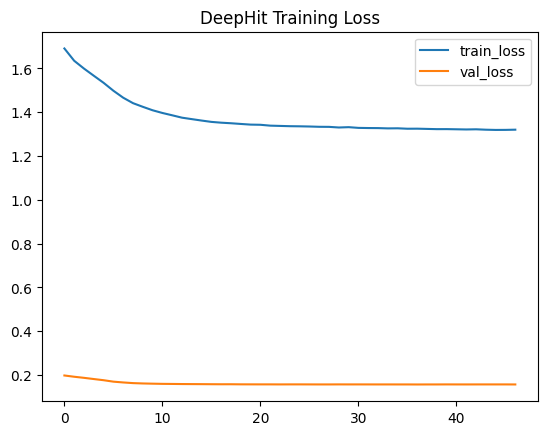

In [4]:
# ===== 4. TRAIN =====
batch_size = 512
epochs = 100

# Callbacks: early stopping + LR decay
callbacks = [
    tt.callbacks.EarlyStopping(patience=10),
    tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4),
]

# Use lower initial LR for more stable training
model.optimizer.set_lr(0.0005)

log = model.fit(
    x_train, y_train_dh,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    val_data=(x_test, y_test_dh),
    verbose=True
)

# Plot training loss
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
log.plot(ax=ax)
ax.set_title('DeepHit Training Loss')
plt.show()

In [5]:
# ===== 5. EVALUATE =====
from pycox.evaluation import EvalSurv

# Fix scipy compatibility (simps renamed to simpson in newer scipy)
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

# Get CIF (cumulative incidence functions) for each risk
cif = model.predict_cif(x_test)

# --- C-index ---
print('=== C-index (time-dependent) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    c_idx = ev.concordance_td()
    print(f'  {risk_name} C-index: {c_idx:.3f}')

# --- Brier Score ---
print('\n=== Integrated Brier Score ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    ev = EvalSurv(
        1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts),
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    time_grid = np.linspace(1, 36, 36)
    ibs = ev.integrated_brier_score(time_grid)
    print(f'  {risk_name} IBS: {ibs:.4f} (lower is better)')

# --- AUC at specific time points ---
print('\n=== AUC at key time points ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    mask = (y_test_evt == 0) | (y_test_evt == risk_idx + 1)
    surv_df_eval = 1 - pd.DataFrame(cif[risk_idx][:, mask], index=labtrans.cuts)
    ev = EvalSurv(
        surv_df_eval,
        y_test_dur[mask],
        (y_test_evt[mask] == risk_idx + 1).astype(float),
        censor_surv='km'
    )
    print(f'  {risk_name}:')
    for t in [6, 12, 24, 36]:
        try:
            auc_t = ev.concordance_td(method="antolini")
            print(f'    t={t:2d} months — C-index: {auc_t:.3f}')
            break
        except:
            print(f'    t={t:2d} months — could not compute')
            break

# --- Lift chart ---
print('\n=== Lift by Decile (at t=12 months) ===')
for risk_idx, risk_name in enumerate(['Default', 'Prepay']):
    # Predicted CIF at month 12
    t12_idx = 11  # 0-indexed
    pred_risk = cif[risk_idx][t12_idx, :]
    actual_event = (y_test_evt == risk_idx + 1).astype(int)
    actual_by_t12 = ((y_test_evt == risk_idx + 1) & (y_test_dur <= 12)).astype(int)

    # Sort by predicted risk, split into deciles
    order = np.argsort(-pred_risk)  # highest risk first
    n = len(order)
    decile_size = n // 10
    baseline_rate = actual_by_t12.mean()

    print(f'  {risk_name} (baseline rate: {baseline_rate:.4f}):')
    for d in range(10):
        idx = order[d * decile_size:(d + 1) * decile_size]
        rate = actual_by_t12[idx].mean()
        lift = rate / baseline_rate if baseline_rate > 0 else 0
        bar = '#' * int(lift * 5)
        print(f'    Decile {d+1:2d}: rate={rate:.4f}  lift={lift:.2f}x  {bar}')

print(f'\nCIF shape: {cif[0].shape} (time_steps x loans)')


=== C-index (time-dependent) ===
  Default C-index: 0.639
  Prepay C-index: 0.626

=== Integrated Brier Score ===
  Default IBS: 0.1767 (lower is better)
  Prepay IBS: 0.6654 (lower is better)

=== AUC at key time points ===
  Default:
    t= 6 months — C-index: 0.634
  Prepay:
    t= 6 months — C-index: 0.621

=== Lift by Decile (at t=12 months) ===
  Default (baseline rate: 0.0065):
    Decile  1: rate=0.0168  lift=2.58x  ############
    Decile  2: rate=0.0122  lift=1.87x  #########
    Decile  3: rate=0.0085  lift=1.31x  ######
    Decile  4: rate=0.0071  lift=1.10x  #####
    Decile  5: rate=0.0044  lift=0.67x  ###
    Decile  6: rate=0.0041  lift=0.64x  ###
    Decile  7: rate=0.0037  lift=0.57x  ##
    Decile  8: rate=0.0035  lift=0.53x  ##
    Decile  9: rate=0.0023  lift=0.35x  #
    Decile 10: rate=0.0025  lift=0.39x  #
  Prepay (baseline rate: 0.0486):
    Decile  1: rate=0.1096  lift=2.25x  ###########
    Decile  2: rate=0.0787  lift=1.62x  ########
    Decile  3: rate=0.0

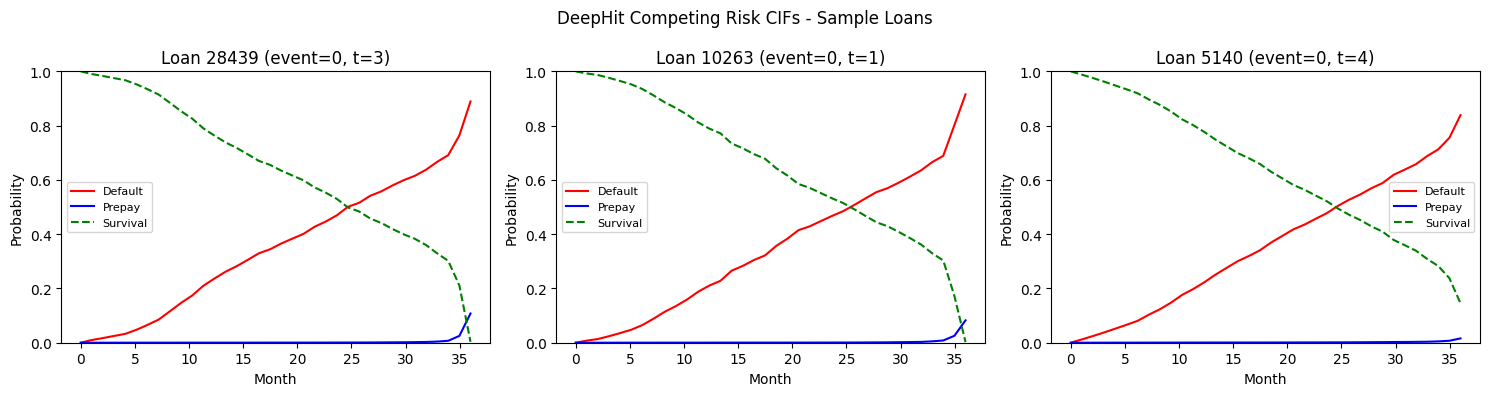

In [6]:
# ===== 6. VISUALIZE: Sample loan CIFs =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_grid = labtrans.cuts

for i, ax in enumerate(axes):
    idx = np.random.randint(len(x_test))
    ax.plot(time_grid, cif[0][:, idx], label='Default', color='red')
    ax.plot(time_grid, cif[1][:, idx], label='Prepay', color='blue')
    ax.plot(time_grid, 1 - cif[0][:, idx] - cif[1][:, idx], label='Survival', color='green', ls='--')
    ax.set_xlabel('Month')
    ax.set_ylabel('Probability')
    ax.set_title(f'Loan {idx} (event={y_test_evt[idx]}, t={y_test_dur[idx]})')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('DeepHit Competing Risk CIFs - Sample Loans')
plt.tight_layout()
plt.show()